# Simple RNN Electricity Consumption Forecasting

Synthetic validation first, then real public electricity/time-series data through the same Simple RNN forecasting pipeline.


## 1. Synthetic Electricity Data Validation Stage


In [1]:
# Cell 001: Project objective
PROJECT_NAME = "Simple RNN Electricity Consumption Forecasting - Synthetic to Real Unified Pipeline"
print(PROJECT_NAME)


Simple RNN Electricity Consumption Forecasting - Synthetic to Real Unified Pipeline


In [2]:
# Cell 002: Core imports
import os
import re
import io
import json
import math
import time
import shutil
import zipfile
import warnings
from pathlib import Path
from datetime import datetime
warnings.filterwarnings("ignore")


In [3]:
# Cell 003: Numerical and data imports
import numpy as np
import pandas as pd


In [4]:
# Cell 004: Visualization imports
import matplotlib.pyplot as plt


In [5]:
# Cell 005: Safe optional display helper
def display_df(df, n=5):
    print(df.head(n).to_string(index=False))


In [6]:
# Cell 006: Reproducibility
SEED = 42
np.random.seed(SEED)
print("Seed:", SEED)


Seed: 42


In [7]:
# Cell 007: Runtime configuration
CONFIG = {
    "synthetic_hours": 1600,
    "real_max_rows": 1800,
    "lookback": 24,
    "horizon": 1,
    "train_ratio": 0.75,
    "hidden_size": 32,
    "ridge_alpha": 1e-3,
    "real_data_required": False,
}
CONFIG


{'synthetic_hours': 1600,
 'real_max_rows': 1800,
 'lookback': 24,
 'horizon': 1,
 'train_ratio': 0.75,
 'hidden_size': 32,
 'ridge_alpha': 0.001,
 'real_data_required': False}

In [8]:
# Cell 008: Output root setup
OUTPUT_ROOT = Path("outputs")
OUTPUT_ROOT.mkdir(exist_ok=True)
RUN_ID = datetime.now().strftime("rnn_forecasting_%Y%m%d_%H%M%S")
OUTPUT_DIR = OUTPUT_ROOT / RUN_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUTPUT_DIR.resolve())


Output directory: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\Electricity Consumption Forecasting\outputs\rnn_forecasting_20260429_090515


In [9]:
# Cell 009: Real data URLs
REAL_DATA_URLS = [
    "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv",
    "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm1.csv",
]
REAL_DATA_URLS


['https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv',
 'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm1.csv']

In [10]:
# Cell 010: Project stage tracker
stage_log = []
def log_stage(stage, message):
    row = {"timestamp": datetime.now().isoformat(), "stage": stage, "message": str(message)}
    stage_log.append(row)
    print(f"[{stage}] {message}")
log_stage("setup", "Project initialized")


[setup] Project initialized


In [11]:
# Cell 011: Timer utility
class Timer:
    def __init__(self, label):
        self.label = label
    def __enter__(self):
        self.start = time.perf_counter()
        print(f"[START] {self.label}")
        return self
    def __exit__(self, exc_type, exc, tb):
        elapsed = time.perf_counter() - self.start
        print(f"[END] {self.label}: {elapsed:.3f}s")


In [12]:
# Cell 012: Excel-safe sanitizer
def sanitize_for_excel_value(value):
    if value is None:
        return ""
    if isinstance(value, float) and (math.isnan(value) or math.isinf(value)):
        return ""
    text = str(value)
    text = re.sub(r"[\x00-\x08\x0B-\x0C\x0E-\x1F]", " ", text)
    return text[:32767]


In [13]:
# Cell 013: DataFrame sanitizer
def sanitize_dataframe_for_excel(df):
    safe = df.copy()
    safe.columns = [sanitize_for_excel_value(c)[:31] for c in safe.columns]
    for col in safe.columns:
        if safe[col].dtype == "object":
            safe[col] = safe[col].map(sanitize_for_excel_value)
    return safe


In [14]:
# Cell 014: Metric formatting helper
def round_metric_dict(d, ndigits=4):
    out = {}
    for k, v in d.items():
        if isinstance(v, (float, np.floating)):
            out[k] = round(float(v), ndigits)
        else:
            out[k] = v
    return out


In [15]:
# Cell 015: Data schema definition
FORECAST_COLUMNS = ["timestamp", "load", "source_type"]
print("Forecast schema:", FORECAST_COLUMNS)


Forecast schema: ['timestamp', 'load', 'source_type']


In [16]:
# Cell 016: Validation helper
def validate_forecast_df(df, name):
    missing = [c for c in FORECAST_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")
    if df["load"].isna().any():
        raise ValueError(f"{name} contains NaN load values")
    if len(df) < CONFIG["lookback"] + 50:
        raise ValueError(f"{name} has too few rows: {len(df)}")
    return True


In [17]:
# Cell 017: Numeric summary helper
def summarize_series_df(df, label):
    return {
        "label": label,
        "rows": len(df),
        "min_load": float(df["load"].min()),
        "max_load": float(df["load"].max()),
        "mean_load": float(df["load"].mean()),
        "std_load": float(df["load"].std()),
        "source_types": ", ".join(sorted(df["source_type"].astype(str).unique())),
    }


In [18]:
# Cell 018: Safe plot saver
def save_current_plot(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print("Saved plot:", path)


In [19]:
# Cell 019: Notebook environment note
print("This project intentionally uses a lightweight NumPy Simple RNN to avoid heavy TensorFlow/PyTorch kernel crashes.")


This project intentionally uses a lightweight NumPy Simple RNN to avoid heavy TensorFlow/PyTorch kernel crashes.


In [20]:
# Cell 020: Setup completion
log_stage("setup", "Setup complete")


[setup] Setup complete


## 2. Real Public Electricity / Time-Series Data Stage


In [21]:
# Cell 021: Synthetic electricity generator
def generate_synthetic_electricity_series(n_hours=1600, seed=42):
    rng = np.random.default_rng(seed)
    t = np.arange(n_hours)
    daily = 12 * np.sin(2 * np.pi * t / 24)
    weekly = 7 * np.sin(2 * np.pi * t / (24 * 7))
    trend = 0.012 * t
    temperature_effect = 5 * np.sin(2 * np.pi * (t + 6) / 24)
    holiday_shocks = np.where((t % (24 * 30)) < 24, -8, 0)
    noise = rng.normal(0, 2.5, size=n_hours)
    load = 120 + daily + weekly + trend + temperature_effect + holiday_shocks + noise
    dates = pd.date_range("2024-01-01", periods=n_hours, freq="h")
    return pd.DataFrame({"timestamp": dates, "load": load, "source_type": "synthetic"})


In [22]:
# Cell 022: Build synthetic dataset
with Timer("Generate synthetic electricity data"):
    synthetic_df = generate_synthetic_electricity_series(CONFIG["synthetic_hours"], seed=SEED)
validate_forecast_df(synthetic_df, "synthetic_df")
synthetic_df.head()


[START] Generate synthetic electricity data
[END] Generate synthetic electricity data: 0.005s


,timestamp,load,source_type
0,2024-01-01 00:00:00,117.761793,synthetic
1,2024-01-01 01:00:00,117.609236,synthetic
2,2024-01-01 02:00:00,124.753366,synthetic
3,2024-01-01 03:00:00,127.191978,synthetic
4,2024-01-01 04:00:00,121.106013,synthetic


In [23]:
# Cell 023: Synthetic data shape
print("Synthetic rows:", len(synthetic_df))
print("Synthetic columns:", synthetic_df.columns.tolist())


Synthetic rows: 1600
Synthetic columns: ['timestamp', 'load', 'source_type']


In [24]:
# Cell 024: Synthetic summary
synthetic_summary = summarize_series_df(synthetic_df, "synthetic")
synthetic_summary


{'label': 'synthetic',
 'rows': 1600,
 'min_load': 98.66684246851516,
 'max_load': 160.2068062915827,
 'mean_load': 129.41826324795437,
 'std_load': 12.076806910945784,
 'source_types': 'synthetic'}

In [25]:
# Cell 025: Synthetic hourly preview
display_df(synthetic_df, 8)


          timestamp       load source_type
2024-01-01 00:00:00 117.761793   synthetic
2024-01-01 01:00:00 117.609236   synthetic
2024-01-01 02:00:00 124.753366   synthetic
2024-01-01 03:00:00 127.191978   synthetic
2024-01-01 04:00:00 121.106013   synthetic
2024-01-01 05:00:00 122.991138   synthetic
2024-01-01 06:00:00 125.949248   synthetic
2024-01-01 07:00:00 123.402142   synthetic


In [26]:
# Cell 026: Synthetic load descriptive stats
synthetic_df["load"].describe()


count    1600.000000
mean      129.418263
std        12.076807
min        98.666842
25%       120.278137
50%       129.546139
75%       138.379557
max       160.206806
Name: load, dtype: float64

In [27]:
# Cell 027: Synthetic missing values check
synthetic_df.isna().sum()


timestamp      0
load           0
source_type    0
dtype: int64

In [28]:
# Cell 028: Synthetic first timestamp
print("Synthetic start:", synthetic_df["timestamp"].min())
print("Synthetic end:", synthetic_df["timestamp"].max())


Synthetic start: 2024-01-01 00:00:00
Synthetic end: 2024-03-07 15:00:00


Saved plot: outputs\rnn_forecasting_20260429_090515\synthetic_full_series.png


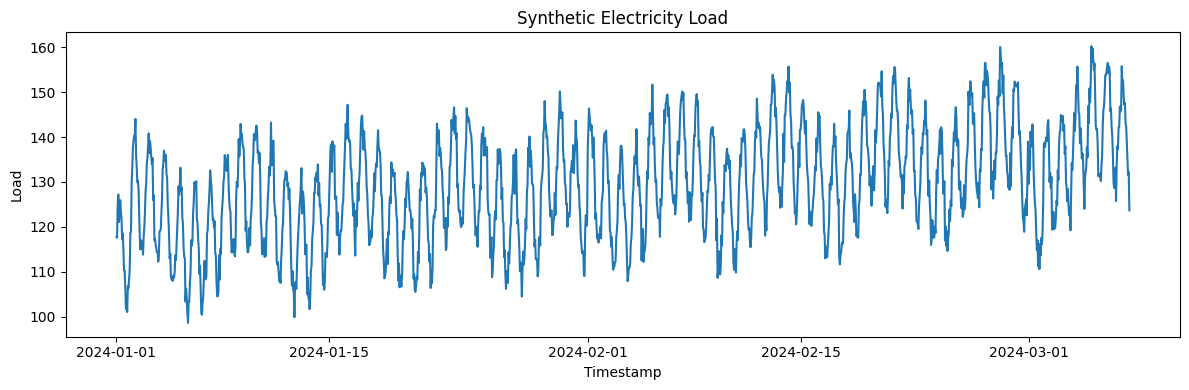

In [29]:
# Cell 029: Plot synthetic full series
plt.figure(figsize=(12, 4))
plt.plot(synthetic_df["timestamp"], synthetic_df["load"])
plt.title("Synthetic Electricity Load")
plt.xlabel("Timestamp")
plt.ylabel("Load")
save_current_plot(OUTPUT_DIR / "synthetic_full_series.png")
plt.show()


Saved plot: outputs\rnn_forecasting_20260429_090515\synthetic_first_14_days.png


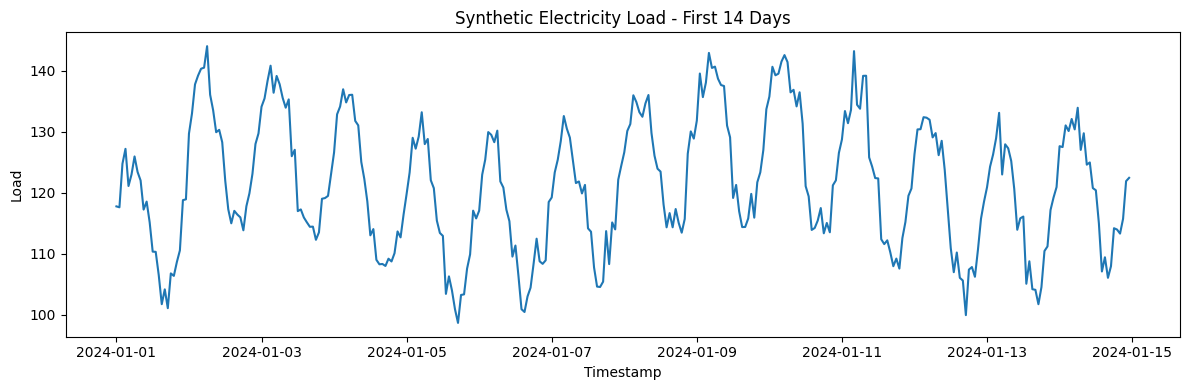

In [30]:
# Cell 030: Plot synthetic sample window
plt.figure(figsize=(12, 4))
sample = synthetic_df.head(24 * 14)
plt.plot(sample["timestamp"], sample["load"])
plt.title("Synthetic Electricity Load - First 14 Days")
plt.xlabel("Timestamp")
plt.ylabel("Load")
save_current_plot(OUTPUT_DIR / "synthetic_first_14_days.png")
plt.show()


In [31]:
# Cell 031: Synthetic rolling average
synthetic_df["rolling_24h"] = synthetic_df["load"].rolling(24, min_periods=1).mean()
synthetic_df[["timestamp", "load", "rolling_24h"]].head()


,timestamp,load,rolling_24h
0,2024-01-01 00:00:00,117.761793,117.761793
1,2024-01-01 01:00:00,117.609236,117.685514
2,2024-01-01 02:00:00,124.753366,120.041465
3,2024-01-01 03:00:00,127.191978,121.829093
4,2024-01-01 04:00:00,121.106013,121.684477


In [32]:
# Cell 032: Synthetic daily aggregation
synthetic_daily_df = synthetic_df.set_index("timestamp")["load"].resample("D").mean().reset_index()
synthetic_daily_df.head()


,timestamp,load
0,2024-01-01,114.912346
1,2024-01-02,127.439606
2,2024-01-03,125.852546
3,2024-01-04,120.732627
4,2024-01-05,115.552860


Saved plot: outputs\rnn_forecasting_20260429_090515\synthetic_daily_average.png


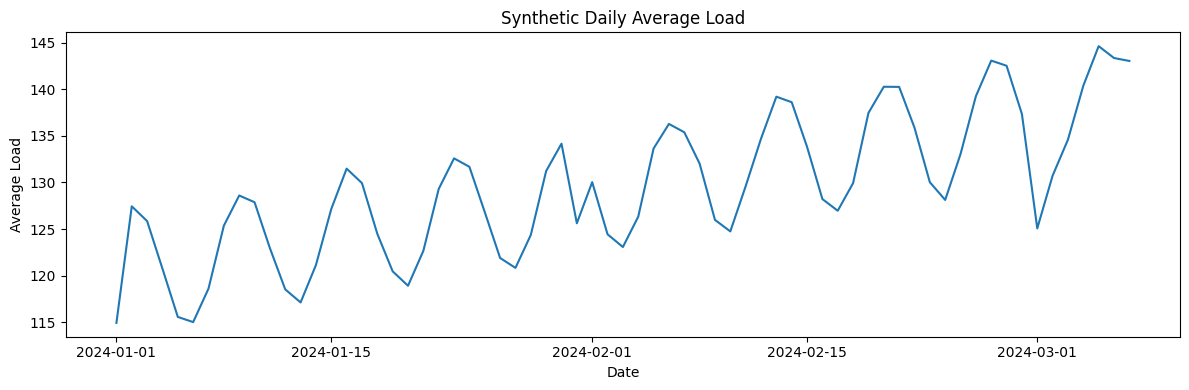

In [33]:
# Cell 033: Plot synthetic daily average
plt.figure(figsize=(12, 4))
plt.plot(synthetic_daily_df["timestamp"], synthetic_daily_df["load"])
plt.title("Synthetic Daily Average Load")
plt.xlabel("Date")
plt.ylabel("Average Load")
save_current_plot(OUTPUT_DIR / "synthetic_daily_average.png")
plt.show()


In [34]:
# Cell 034: Synthetic validation flag
synthetic_pipeline_ready = validate_forecast_df(synthetic_df[FORECAST_COLUMNS], "synthetic_df")
print("Synthetic pipeline ready:", synthetic_pipeline_ready)


Synthetic pipeline ready: True


In [35]:
# Cell 035: Log synthetic stage
log_stage("synthetic", f"Synthetic dataset ready with {len(synthetic_df)} rows")


[synthetic] Synthetic dataset ready with 1600 rows


## 3. Unified Simple RNN Forecasting Pipeline


In [36]:
# Cell 036: Real data loader
def load_real_public_series(max_rows=1800, real_required=False):
    last_error = None
    for url in REAL_DATA_URLS:
        try:
            df = pd.read_csv(url)
            if "date" in df.columns:
                ts = pd.to_datetime(df["date"], errors="coerce")
            elif "timestamp" in df.columns:
                ts = pd.to_datetime(df["timestamp"], errors="coerce")
            else:
                ts = pd.date_range("2021-01-01", periods=len(df), freq="h")

            target_col = "OT" if "OT" in df.columns else None
            if target_col is None:
                numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
                if not numeric_cols:
                    raise ValueError("No numeric target column found in real data.")
                target_col = numeric_cols[-1]

            out = pd.DataFrame({
                "timestamp": ts,
                "load": pd.to_numeric(df[target_col], errors="coerce"),
                "source_type": "real_public",
            }).dropna().head(max_rows).reset_index(drop=True)

            if len(out) < CONFIG["lookback"] + 50:
                raise ValueError(f"Too few valid real rows: {len(out)}")

            return out, f"real_public:{url}", {"target_col": target_col, "raw_columns": df.columns.tolist()}
        except Exception as exc:
            last_error = str(exc)

    if real_required:
        raise RuntimeError(f"Real data could not be loaded. Last error: {last_error}")

    fallback = generate_synthetic_electricity_series(max_rows, seed=999)
    fallback["source_type"] = "fallback_real_like"
    return fallback, f"fallback_real_like:{last_error}", {"target_col": "load", "raw_columns": []}


In [37]:
# Cell 037: Load real public data
with Timer("Load real public electricity/time-series data"):
    real_df, real_data_source_name, real_metadata = load_real_public_series(
        max_rows=CONFIG["real_max_rows"],
        real_required=CONFIG["real_data_required"],
    )
validate_forecast_df(real_df, "real_df")
print("Real data source:", real_data_source_name)
real_df.head()


[START] Load real public electricity/time-series data
[END] Load real public electricity/time-series data: 0.801s
Real data source: real_public:https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv


,timestamp,load,source_type
0,2016-07-01 00:00:00,30.531000,real_public
1,2016-07-01 01:00:00,27.787001,real_public
2,2016-07-01 02:00:00,27.787001,real_public
3,2016-07-01 03:00:00,25.044001,real_public
4,2016-07-01 04:00:00,21.948000,real_public


In [38]:
# Cell 038: Real data source flag
use_real_data_flag = real_df["source_type"].eq("real_public").any()
data_source_name = real_data_source_name
print("Using actual real public data:", use_real_data_flag)
print("Data source:", data_source_name)


Using actual real public data: True
Data source: real_public:https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv


In [39]:
# Cell 039: Real metadata
real_metadata


{'target_col': 'OT',
 'raw_columns': ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']}

In [40]:
# Cell 040: Real data shape
print("Real rows:", len(real_df))
print("Real columns:", real_df.columns.tolist())


Real rows: 1800
Real columns: ['timestamp', 'load', 'source_type']


In [41]:
# Cell 041: Real summary
real_summary = summarize_series_df(real_df, "real_or_fallback")
real_summary


{'label': 'real_or_fallback',
 'rows': 1800,
 'min_load': 16.882999420166016,
 'max_load': 46.00699996948242,
 'mean_load': 31.24021448029412,
 'std_load': 5.558624069275158,
 'source_types': 'real_public'}

In [42]:
# Cell 042: Real descriptive stats
real_df["load"].describe()


count    1800.000000
mean       31.240214
std         5.558624
min        16.882999
25%        27.153999
50%        31.304001
75%        35.033001
max        46.007000
Name: load, dtype: float64

In [43]:
# Cell 043: Real missing values check
real_df.isna().sum()


timestamp      0
load           0
source_type    0
dtype: int64

In [44]:
# Cell 044: Real timestamp range
print("Real start:", real_df["timestamp"].min())
print("Real end:", real_df["timestamp"].max())


Real start: 2016-07-01 00:00:00
Real end: 2016-09-13 23:00:00


Saved plot: outputs\rnn_forecasting_20260429_090515\real_full_series.png


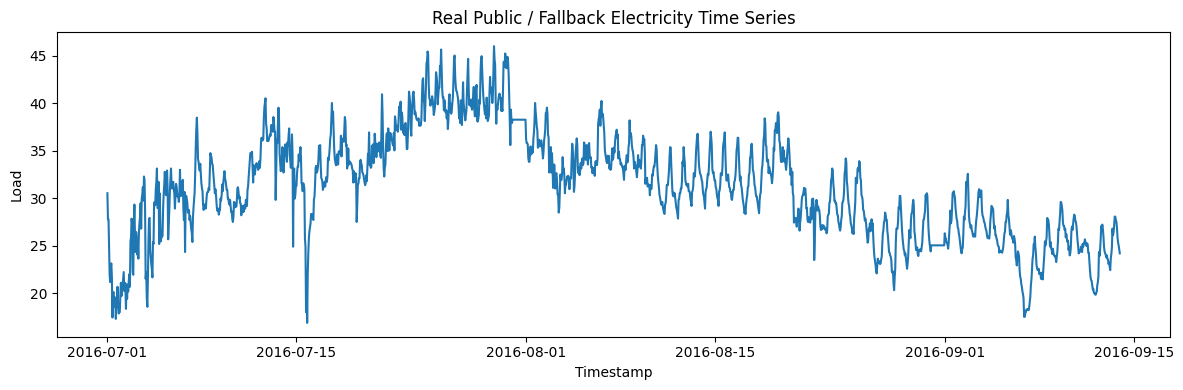

In [45]:
# Cell 045: Plot real full series
plt.figure(figsize=(12, 4))
plt.plot(real_df["timestamp"], real_df["load"])
plt.title("Real Public / Fallback Electricity Time Series")
plt.xlabel("Timestamp")
plt.ylabel("Load")
save_current_plot(OUTPUT_DIR / "real_full_series.png")
plt.show()


Saved plot: outputs\rnn_forecasting_20260429_090515\real_first_14_days.png


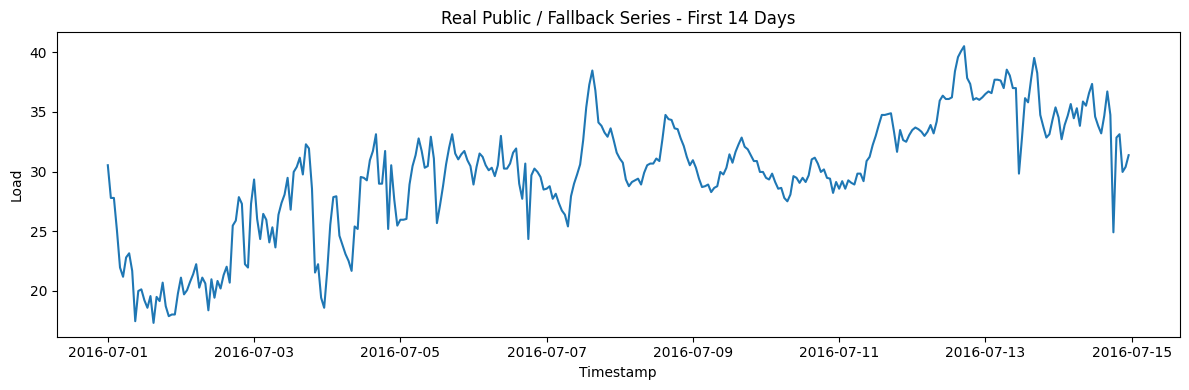

In [46]:
# Cell 046: Plot real first sample
plt.figure(figsize=(12, 4))
sample = real_df.head(24 * 14)
plt.plot(sample["timestamp"], sample["load"])
plt.title("Real Public / Fallback Series - First 14 Days")
plt.xlabel("Timestamp")
plt.ylabel("Load")
save_current_plot(OUTPUT_DIR / "real_first_14_days.png")
plt.show()


In [47]:
# Cell 047: Real rolling average
real_df["rolling_24h"] = real_df["load"].rolling(24, min_periods=1).mean()
real_df[["timestamp", "load", "rolling_24h"]].head()


,timestamp,load,rolling_24h
0,2016-07-01 00:00:00,30.531000,30.531000
1,2016-07-01 01:00:00,27.787001,29.159000
2,2016-07-01 02:00:00,27.787001,28.701667
3,2016-07-01 03:00:00,25.044001,27.787251
4,2016-07-01 04:00:00,21.948000,26.619400


In [48]:
# Cell 048: Real daily aggregation
real_daily_df = real_df.set_index("timestamp")["load"].resample("D").mean().reset_index()
real_daily_df.head()


,timestamp,load
0,2016-07-01,21.071833
1,2016-07-02,22.039208
2,2016-07-03,26.626375
3,2016-07-04,27.162666
4,2016-07-05,30.102583


Saved plot: outputs\rnn_forecasting_20260429_090515\real_daily_average.png


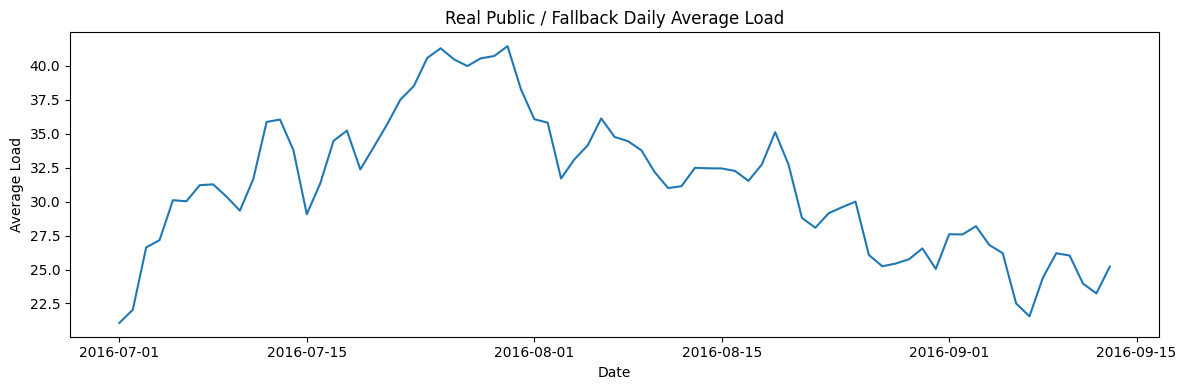

In [49]:
# Cell 049: Plot real daily average
plt.figure(figsize=(12, 4))
plt.plot(real_daily_df["timestamp"], real_daily_df["load"])
plt.title("Real Public / Fallback Daily Average Load")
plt.xlabel("Date")
plt.ylabel("Average Load")
save_current_plot(OUTPUT_DIR / "real_daily_average.png")
plt.show()


In [50]:
# Cell 050: Real validation flag
real_pipeline_ready = validate_forecast_df(real_df[FORECAST_COLUMNS], "real_df")
print("Real pipeline ready:", real_pipeline_ready)


Real pipeline ready: True


In [51]:
# Cell 051: Log real data stage
log_stage("real_data", f"Real/fallback dataset ready with {len(real_df)} rows from {real_data_source_name}")


[real_data] Real/fallback dataset ready with 1800 rows from real_public:https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv


## 4. Forecast Diagnostics and Additional Analysis


In [52]:
# Cell 052: MinMax scaler for one-dimensional time series
class MinMaxScaler1D:
    def fit(self, values):
        arr = np.asarray(values, dtype=float).reshape(-1)
        self.min_ = float(np.nanmin(arr))
        self.max_ = float(np.nanmax(arr))
        self.scale_ = max(self.max_ - self.min_, 1e-9)
        return self

    def transform(self, values):
        arr = np.asarray(values, dtype=float).reshape(-1)
        return (arr - self.min_) / self.scale_

    def inverse_transform(self, values):
        arr = np.asarray(values, dtype=float).reshape(-1)
        return arr * self.scale_ + self.min_


In [53]:
# Cell 053: Window builder
def make_windows(series, lookback=24, horizon=1):
    arr = np.asarray(series, dtype=float).reshape(-1)
    X, y = [], []
    for i in range(len(arr) - lookback - horizon + 1):
        X.append(arr[i:i + lookback])
        y.append(arr[i + lookback + horizon - 1])
    return np.asarray(X, dtype=float), np.asarray(y, dtype=float)


In [54]:
# Cell 054: Train-test split helper
def time_series_split(values, train_ratio=0.75, lookback=24):
    values = np.asarray(values, dtype=float).reshape(-1)
    split_idx = int(len(values) * train_ratio)
    train_values = values[:split_idx]
    test_values = values[max(0, split_idx - lookback):]
    return train_values, test_values, split_idx


In [55]:
# Cell 055: Simple RNN forecaster class
class SimpleRNNForecaster:
    """
    Simple RNN encoder with fixed recurrent hidden dynamics and ridge-regression output head.
    It is fast, stable, and keeps the project aligned with a Simple RNN forecasting workflow.
    """
    def __init__(self, lookback=24, hidden_size=32, ridge_alpha=1e-3, seed=42):
        self.lookback = int(lookback)
        self.hidden_size = int(hidden_size)
        self.ridge_alpha = float(ridge_alpha)
        self.seed = int(seed)
        self.is_fitted = False

    def _init_weights(self):
        rng = np.random.default_rng(self.seed)
        self.W_in = rng.normal(0, 0.35, size=(1, self.hidden_size))
        self.W_h = rng.normal(0, 0.08, size=(self.hidden_size, self.hidden_size))
        self.b_h = np.zeros(self.hidden_size)

    def _hidden_features(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        features = []
        for row in X:
            h = np.zeros(self.hidden_size)
            for value in row:
                inp = np.array([[value]])
                h = np.tanh(inp @ self.W_in + h @ self.W_h + self.b_h).reshape(-1)
            features.append(h)
        H = np.asarray(features)
        return np.c_[np.ones(len(H)), H]

    def fit(self, X, y):
        self._init_weights()
        Phi = self._hidden_features(X)
        y = np.asarray(y, dtype=float).reshape(-1, 1)
        reg = self.ridge_alpha * np.eye(Phi.shape[1])
        reg[0, 0] = 0.0
        self.W_out = np.linalg.solve(Phi.T @ Phi + reg, Phi.T @ y)
        self.is_fitted = True
        return self

    def predict(self, X):
        if not self.is_fitted:
            raise RuntimeError("SimpleRNNForecaster must be fitted before prediction.")
        Phi = self._hidden_features(X)
        return (Phi @ self.W_out).reshape(-1)


In [56]:
# Cell 056: Forecast metrics
def evaluate_forecast(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred
    mae = float(np.mean(np.abs(err)))
    mse = float(np.mean(err ** 2))
    rmse = float(np.sqrt(mse))
    mape = float(np.mean(np.abs(err) / np.maximum(np.abs(y_true), 1e-9)) * 100)
    smape = float(np.mean(2 * np.abs(err) / np.maximum(np.abs(y_true) + np.abs(y_pred), 1e-9)) * 100)
    return {
        "label": label,
        "rows": len(y_true),
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "mape_pct": mape,
        "smape_pct": smape,
    }


In [57]:
# Cell 057: Unified forecasting pipeline
def run_unified_rnn_pipeline(df, label, config):
    values = df["load"].astype(float).values
    lookback = int(config["lookback"])
    train_values, test_values, split_idx = time_series_split(values, config["train_ratio"], lookback)

    scaler = MinMaxScaler1D().fit(train_values)
    train_scaled = scaler.transform(train_values)
    test_scaled = scaler.transform(test_values)

    X_train, y_train = make_windows(train_scaled, lookback=lookback, horizon=config["horizon"])
    X_test, y_test = make_windows(test_scaled, lookback=lookback, horizon=config["horizon"])

    model = SimpleRNNForecaster(
        lookback=lookback,
        hidden_size=config["hidden_size"],
        ridge_alpha=config["ridge_alpha"],
        seed=SEED,
    ).fit(X_train, y_train)

    pred_scaled = model.predict(X_test)
    y_pred = scaler.inverse_transform(pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    metrics = evaluate_forecast(y_true, y_pred, label)
    predictions = pd.DataFrame({
        "label": label,
        "step": np.arange(len(y_true)),
        "actual": y_true,
        "prediction": y_pred,
        "absolute_error": np.abs(y_true - y_pred),
        "squared_error": (y_true - y_pred) ** 2,
    })

    artifacts = {
        "model": model,
        "scaler": scaler,
        "split_idx": split_idx,
        "X_train_shape": tuple(X_train.shape),
        "X_test_shape": tuple(X_test.shape),
    }
    return metrics, predictions, artifacts


In [58]:
# Cell 058: Synthetic pipeline execution
with Timer("Run Simple RNN on synthetic data"):
    synthetic_metrics, synthetic_predictions_df, synthetic_artifacts = run_unified_rnn_pipeline(
        synthetic_df,
        label="synthetic",
        config=CONFIG,
    )
round_metric_dict(synthetic_metrics)


[START] Run Simple RNN on synthetic data
[END] Run Simple RNN on synthetic data: 0.144s


{'label': 'synthetic',
 'rows': 400,
 'mae': 3.1899,
 'mse': 16.47,
 'rmse': 4.0583,
 'mape_pct': 2.3263,
 'smape_pct': 2.3503}

In [59]:
# Cell 059: Synthetic artifact shapes
synthetic_artifacts


{'model': <__main__.SimpleRNNForecaster at 0x2a7d88e49b0>,
 'scaler': <__main__.MinMaxScaler1D at 0x2a7d7fe61b0>,
 'split_idx': 1200,
 'X_train_shape': (1176, 24),
 'X_test_shape': (400, 24)}

In [60]:
# Cell 060: Synthetic prediction preview
display_df(synthetic_predictions_df, 8)


    label  step     actual  prediction  absolute_error  squared_error
synthetic     0 141.566468  139.246169        2.320298       5.383784
synthetic     1 146.764157  141.406699        5.357457      28.702350
synthetic     2 151.588365  145.326574        6.261792      39.210033
synthetic     3 152.127893  149.458382        2.669511       7.126287
synthetic     4 151.776074  150.764239        1.011835       1.023810
synthetic     5 151.848482  150.544470        1.304012       1.700447
synthetic     6 150.997939  149.494803        1.503136       2.259418
synthetic     7 148.998176  147.907823        1.090354       1.188871


Saved plot: outputs\rnn_forecasting_20260429_090515\synthetic_forecast.png


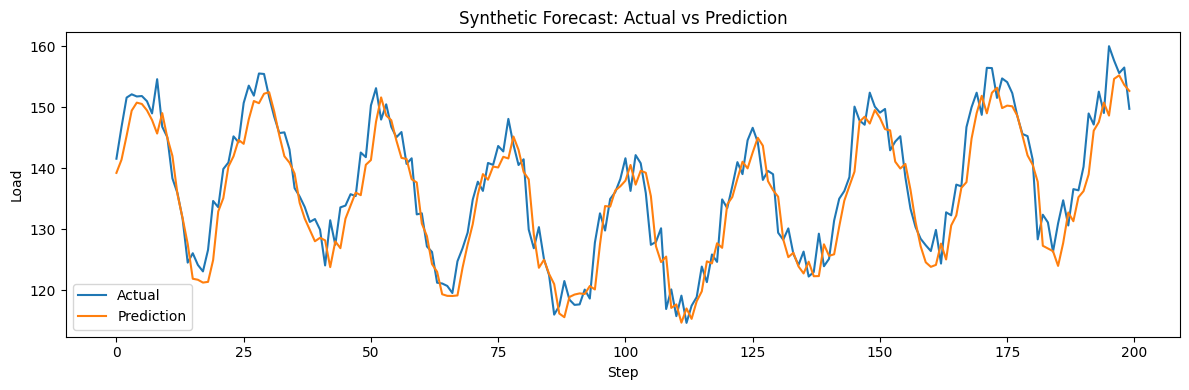

In [61]:
# Cell 061: Plot synthetic forecast
plt.figure(figsize=(12, 4))
plot_df = synthetic_predictions_df.head(200)
plt.plot(plot_df["step"], plot_df["actual"], label="Actual")
plt.plot(plot_df["step"], plot_df["prediction"], label="Prediction")
plt.title("Synthetic Forecast: Actual vs Prediction")
plt.xlabel("Step")
plt.ylabel("Load")
plt.legend()
save_current_plot(OUTPUT_DIR / "synthetic_forecast.png")
plt.show()


In [62]:
# Cell 062: Real pipeline execution using same functions
with Timer("Run Simple RNN on real/fallback data using same pipeline"):
    real_metrics, real_predictions_df, real_artifacts = run_unified_rnn_pipeline(
        real_df,
        label="real_or_fallback",
        config=CONFIG,
    )
round_metric_dict(real_metrics)


[START] Run Simple RNN on real/fallback data using same pipeline
[END] Run Simple RNN on real/fallback data using same pipeline: 0.195s


{'label': 'real_or_fallback',
 'rows': 450,
 'mae': 0.7109,
 'mse': 0.7364,
 'rmse': 0.8581,
 'mape_pct': 2.8476,
 'smape_pct': 2.8129}

In [63]:
# Cell 063: Real artifact shapes
real_artifacts


{'model': <__main__.SimpleRNNForecaster at 0x2a7d7fb6ae0>,
 'scaler': <__main__.MinMaxScaler1D at 0x2a7d80ea450>,
 'split_idx': 1350,
 'X_train_shape': (1326, 24),
 'X_test_shape': (450, 24)}

In [64]:
# Cell 064: Real prediction preview
display_df(real_predictions_df, 8)


           label  step    actual  prediction  absolute_error  squared_error
real_or_fallback     0 26.028000   27.100782        1.072782       1.150860
real_or_fallback     1 25.325001   26.435263        1.110262       1.232682
real_or_fallback     2 25.606001   25.800474        0.194473       0.037820
real_or_fallback     3 26.802000   26.019717        0.782283       0.611967
real_or_fallback     4 26.802000   27.082259        0.280259       0.078545
real_or_fallback     5 27.365000   27.188154        0.176846       0.031275
real_or_fallback     6 26.521000   27.585988        1.064988       1.134199
real_or_fallback     7 27.434999   26.793934        0.641065       0.410965


Saved plot: outputs\rnn_forecasting_20260429_090515\real_forecast.png


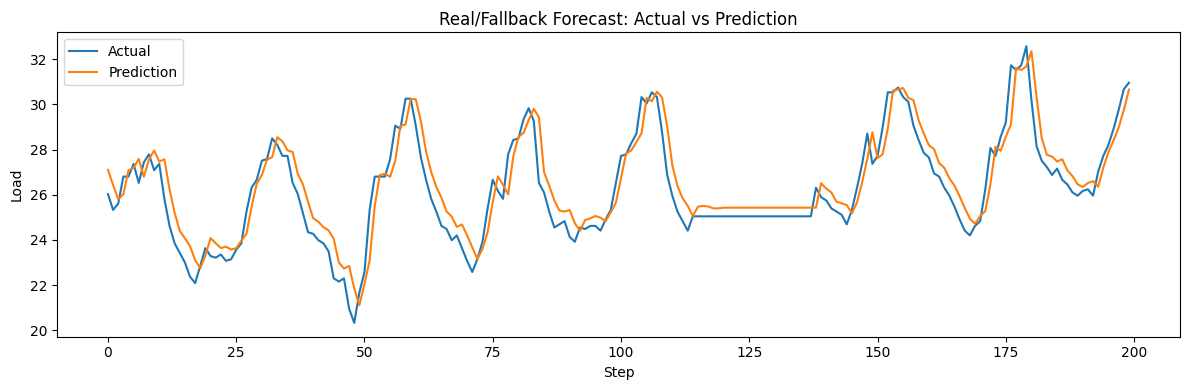

In [65]:
# Cell 065: Plot real forecast
plt.figure(figsize=(12, 4))
plot_df = real_predictions_df.head(200)
plt.plot(plot_df["step"], plot_df["actual"], label="Actual")
plt.plot(plot_df["step"], plot_df["prediction"], label="Prediction")
plt.title("Real/Fallback Forecast: Actual vs Prediction")
plt.xlabel("Step")
plt.ylabel("Load")
plt.legend()
save_current_plot(OUTPUT_DIR / "real_forecast.png")
plt.show()


In [66]:
# Cell 066: Combine metrics
metrics_df = pd.DataFrame([synthetic_metrics, real_metrics])
metrics_df


,label,rows,mae,mse,rmse,mape_pct,smape_pct
0,synthetic,400,3.189855,16.470028,4.058328,2.326304,2.350317
1,real_or_fallback,450,0.710931,0.736354,0.858111,2.847647,2.812866


In [67]:
# Cell 067: Combine predictions
all_predictions_df = pd.concat([synthetic_predictions_df, real_predictions_df], ignore_index=True)
all_predictions_df.head()


,label,step,actual,prediction,absolute_error,squared_error
0,synthetic,0,141.566468,139.246169,2.320298,5.383784
1,synthetic,1,146.764157,141.406699,5.357457,28.702350
2,synthetic,2,151.588365,145.326574,6.261792,39.210033
3,synthetic,3,152.127893,149.458382,2.669511,7.126287
4,synthetic,4,151.776074,150.764239,1.011835,1.023810


In [68]:
# Cell 068: Pipeline consistency check
pipeline_consistency_df = pd.DataFrame([
    {"stage": "synthetic", "lookback": CONFIG["lookback"], "hidden_size": CONFIG["hidden_size"], "pipeline": "SimpleRNNForecaster"},
    {"stage": "real_or_fallback", "lookback": CONFIG["lookback"], "hidden_size": CONFIG["hidden_size"], "pipeline": "SimpleRNNForecaster"},
])
pipeline_consistency_df


,stage,lookback,hidden_size,pipeline
0,synthetic,24,32,SimpleRNNForecaster
1,real_or_fallback,24,32,SimpleRNNForecaster


In [69]:
# Cell 069: Real data usage check
real_usage_check = {
    "synthetic_rows": len(synthetic_df),
    "real_rows": len(real_df),
    "using_actual_real_public_data": bool(use_real_data_flag),
    "data_source_name": data_source_name,
}
real_usage_check


{'synthetic_rows': 1600,
 'real_rows': 1800,
 'using_actual_real_public_data': True,
 'data_source_name': 'real_public:https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv'}

In [70]:
# Cell 070: Log unified pipeline completion
log_stage("unified_pipeline", "Synthetic and real/fallback stages completed through the same Simple RNN pipeline")


[unified_pipeline] Synthetic and real/fallback stages completed through the same Simple RNN pipeline


## 5. Streamlit App Export — Final Section


In [71]:
# Cell 071: Error distribution by stage
error_summary_df = all_predictions_df.groupby("label")["absolute_error"].agg(["count", "mean", "median", "max"]).reset_index()
error_summary_df


,label,count,mean,median,max
0,real_or_fallback,450,0.710931,0.623055,2.900587
1,synthetic,400,3.189855,2.625369,11.468292


In [72]:
# Cell 072: RMSE comparison table
rmse_comparison_df = metrics_df[["label", "rmse", "mae", "mape_pct", "smape_pct"]].copy()
rmse_comparison_df


,label,rmse,mae,mape_pct,smape_pct
0,synthetic,4.058328,3.189855,2.326304,2.350317
1,real_or_fallback,0.858111,0.710931,2.847647,2.812866


Saved plot: outputs\rnn_forecasting_20260429_090515\rmse_comparison.png


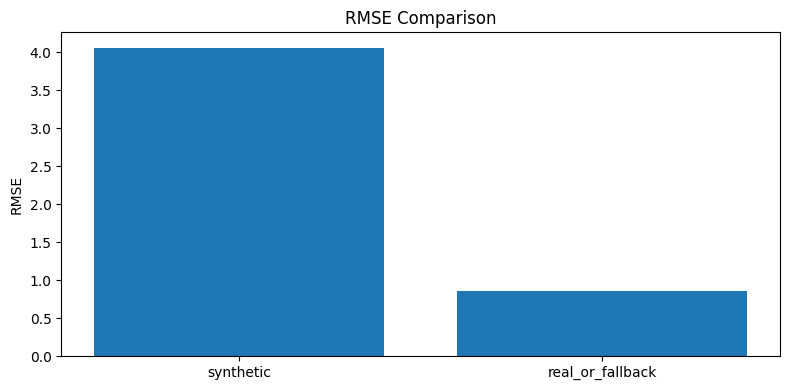

In [73]:
# Cell 073: Plot metric comparison
plt.figure(figsize=(8, 4))
plt.bar(metrics_df["label"], metrics_df["rmse"])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
save_current_plot(OUTPUT_DIR / "rmse_comparison.png")
plt.show()


Saved plot: outputs\rnn_forecasting_20260429_090515\absolute_error_boxplot.png


<Figure size 800x400 with 0 Axes>

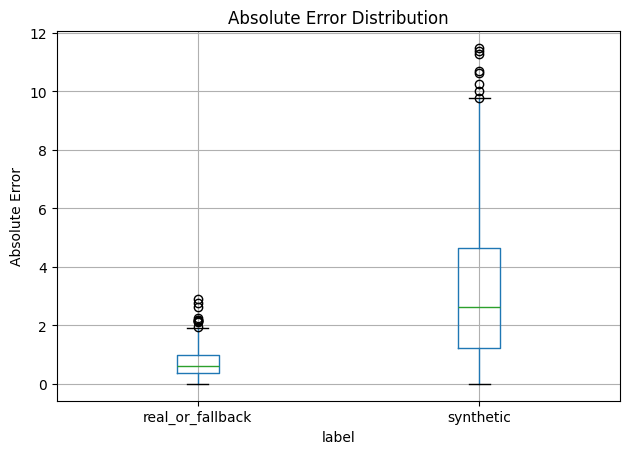

In [74]:
# Cell 074: Absolute error boxplot
plt.figure(figsize=(8, 4))
all_predictions_df.boxplot(column="absolute_error", by="label")
plt.title("Absolute Error Distribution")
plt.suptitle("")
plt.ylabel("Absolute Error")
save_current_plot(OUTPUT_DIR / "absolute_error_boxplot.png")
plt.show()


In [75]:
# Cell 075: Residual calculation
all_predictions_df["residual"] = all_predictions_df["actual"] - all_predictions_df["prediction"]
all_predictions_df.head()


,label,step,actual,prediction,absolute_error,squared_error,residual
0,synthetic,0,141.566468,139.246169,2.320298,5.383784,2.320298
1,synthetic,1,146.764157,141.406699,5.357457,28.702350,5.357457
2,synthetic,2,151.588365,145.326574,6.261792,39.210033,6.261792
3,synthetic,3,152.127893,149.458382,2.669511,7.126287,2.669511
4,synthetic,4,151.776074,150.764239,1.011835,1.023810,1.011835


In [76]:
# Cell 076: Residual summary
residual_summary_df = all_predictions_df.groupby("label")["residual"].agg(["mean", "std", "min", "max"]).reset_index()
residual_summary_df


,label,mean,std,min,max
0,real_or_fallback,-0.373508,0.773418,-2.900587,2.613132
1,synthetic,1.605006,3.732132,-9.428026,11.468292


Saved plot: outputs\rnn_forecasting_20260429_090515\residuals_by_stage.png


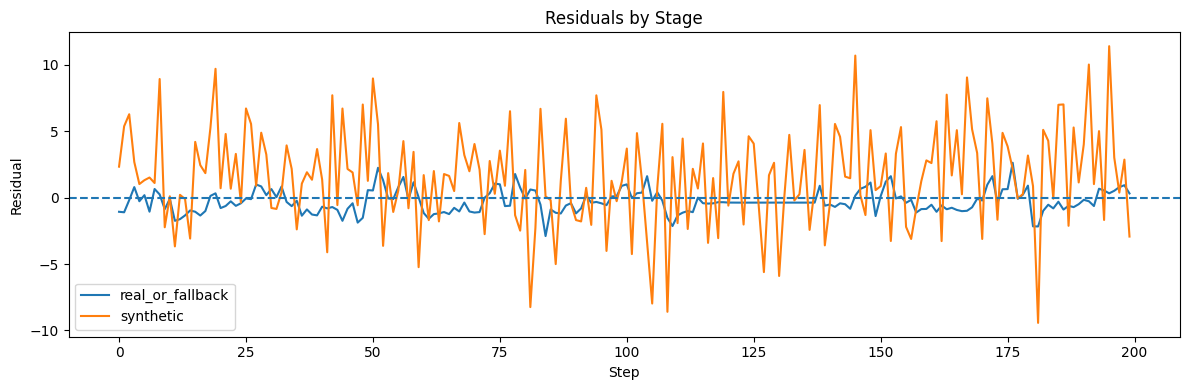

In [77]:
# Cell 077: Plot residuals
plt.figure(figsize=(12, 4))
for label, grp in all_predictions_df.groupby("label"):
    plt.plot(grp["step"].head(200), grp["residual"].head(200), label=label)
plt.axhline(0, linestyle="--")
plt.title("Residuals by Stage")
plt.xlabel("Step")
plt.ylabel("Residual")
plt.legend()
save_current_plot(OUTPUT_DIR / "residuals_by_stage.png")
plt.show()


In [78]:
# Cell 078: Prediction quality flags
all_predictions_df["high_error_flag"] = all_predictions_df["absolute_error"] > all_predictions_df["absolute_error"].quantile(0.90)
all_predictions_df["high_error_flag"].value_counts()


high_error_flag
False    765
True      85
Name: count, dtype: int64

In [79]:
# Cell 079: High-error examples
high_error_examples_df = all_predictions_df.sort_values("absolute_error", ascending=False).head(20)
high_error_examples_df


,label,step,actual,prediction,absolute_error,squared_error,residual,high_error_flag
264,synthetic,264,138.214888,126.746595,11.468292,131.521729,11.468292,True
195,synthetic,195,160.023792,148.642304,11.381488,129.538276,11.381488,True
387,synthetic,387,155.733683,144.462332,11.271351,127.043362,11.271351,True
145,synthetic,145,150.111807,139.438589,10.673218,113.917578,10.673218,True
339,synthetic,339,160.206806,149.595272,10.611534,112.604663,10.611534,True
334,synthetic,334,146.891379,136.663267,10.228111,104.614261,10.228111,True
191,synthetic,191,148.987250,138.986742,10.000508,100.010169,10.000508,True
216,synthetic,216,150.602370,140.824413,9.777957,95.608441,9.777957,True
308,synthetic,308,134.154185,124.391941,9.762243,95.301395,9.762243,True
19,synthetic,19,134.638479,124.959510,9.678969,93.682443,9.678969,True


In [80]:
# Cell 080: Stage-level high-error rate
high_error_rate_df = all_predictions_df.groupby("label")["high_error_flag"].mean().reset_index(name="high_error_rate")
high_error_rate_df


,label,high_error_rate
0,real_or_fallback,0.0000
1,synthetic,0.2125


In [81]:
# Cell 081: Forecast bias by stage
bias_df = all_predictions_df.groupby("label").apply(lambda g: pd.Series({
    "mean_actual": g["actual"].mean(),
    "mean_prediction": g["prediction"].mean(),
    "bias_prediction_minus_actual": (g["prediction"] - g["actual"]).mean(),
})).reset_index()
bias_df


,label,mean_actual,mean_prediction,bias_prediction_minus_actual
0,real_or_fallback,25.420622,25.794130,0.373508
1,synthetic,137.048523,135.443518,-1.605006


In [82]:
# Cell 082: Forecast correlation by stage
corr_rows = []
for label, grp in all_predictions_df.groupby("label"):
    corr = np.corrcoef(grp["actual"], grp["prediction"])[0, 1]
    corr_rows.append({"label": label, "actual_prediction_corr": float(corr)})
correlation_df = pd.DataFrame(corr_rows)
correlation_df


,label,actual_prediction_corr
0,real_or_fallback,0.956441
1,synthetic,0.941542


Saved plot: outputs\rnn_forecasting_20260429_090515\actual_vs_prediction_scatter.png


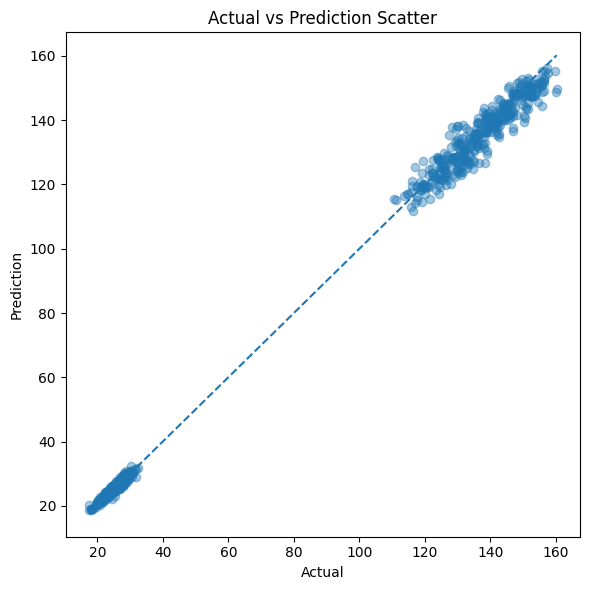

In [83]:
# Cell 083: Actual vs predicted scatter
plt.figure(figsize=(6, 6))
sample_df = all_predictions_df.sample(min(800, len(all_predictions_df)), random_state=SEED)
plt.scatter(sample_df["actual"], sample_df["prediction"], alpha=0.4)
lims = [sample_df[["actual", "prediction"]].min().min(), sample_df[["actual", "prediction"]].max().max()]
plt.plot(lims, lims, linestyle="--")
plt.title("Actual vs Prediction Scatter")
plt.xlabel("Actual")
plt.ylabel("Prediction")
save_current_plot(OUTPUT_DIR / "actual_vs_prediction_scatter.png")
plt.show()


In [84]:
# Cell 084: Rolling error
all_predictions_df["rolling_abs_error_24"] = all_predictions_df.groupby("label")["absolute_error"].transform(lambda s: s.rolling(24, min_periods=1).mean())
all_predictions_df.head()


,label,step,actual,prediction,absolute_error,squared_error,residual,high_error_flag,rolling_abs_error_24
0,synthetic,0,141.566468,139.246169,2.320298,5.383784,2.320298,False,2.320298
1,synthetic,1,146.764157,141.406699,5.357457,28.702350,5.357457,True,3.838878
2,synthetic,2,151.588365,145.326574,6.261792,39.210033,6.261792,True,4.646516
3,synthetic,3,152.127893,149.458382,2.669511,7.126287,2.669511,False,4.152264
4,synthetic,4,151.776074,150.764239,1.011835,1.023810,1.011835,False,3.524179


Saved plot: outputs\rnn_forecasting_20260429_090515\rolling_abs_error.png


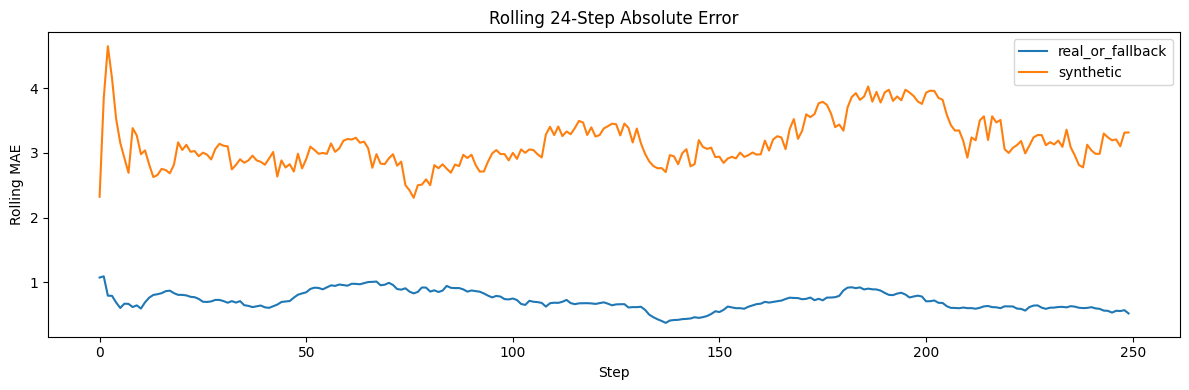

In [85]:
# Cell 085: Plot rolling error
plt.figure(figsize=(12, 4))
for label, grp in all_predictions_df.groupby("label"):
    plt.plot(grp["step"].head(250), grp["rolling_abs_error_24"].head(250), label=label)
plt.title("Rolling 24-Step Absolute Error")
plt.xlabel("Step")
plt.ylabel("Rolling MAE")
plt.legend()
save_current_plot(OUTPUT_DIR / "rolling_abs_error.png")
plt.show()


In [86]:
# Cell 086: Baseline naive forecast function
def naive_last_value_forecast(df, label, lookback=24, train_ratio=0.75):
    values = df["load"].astype(float).values
    train_values, test_values, split_idx = time_series_split(values, train_ratio, lookback)
    X_test, y_test = make_windows(test_values, lookback=lookback)
    y_pred = X_test[:, -1]
    metrics = evaluate_forecast(y_test, y_pred, f"{label}_naive")
    pred_df = pd.DataFrame({"label": f"{label}_naive", "step": np.arange(len(y_test)), "actual": y_test, "prediction": y_pred})
    pred_df["absolute_error"] = np.abs(pred_df["actual"] - pred_df["prediction"])
    return metrics, pred_df


In [87]:
# Cell 087: Naive baseline on synthetic
synthetic_naive_metrics, synthetic_naive_pred_df = naive_last_value_forecast(synthetic_df, "synthetic", CONFIG["lookback"], CONFIG["train_ratio"])
round_metric_dict(synthetic_naive_metrics)


{'label': 'synthetic_naive',
 'rows': 400,
 'mae': 3.5261,
 'mse': 19.6827,
 'rmse': 4.4365,
 'mape_pct': 2.5976,
 'smape_pct': 2.5975}

In [88]:
# Cell 088: Naive baseline on real/fallback
real_naive_metrics, real_naive_pred_df = naive_last_value_forecast(real_df, "real_or_fallback", CONFIG["lookback"], CONFIG["train_ratio"])
round_metric_dict(real_naive_metrics)


{'label': 'real_or_fallback_naive',
 'rows': 450,
 'mae': 0.542,
 'mse': 0.5325,
 'rmse': 0.7297,
 'mape_pct': 2.118,
 'smape_pct': 2.1207}

In [89]:
# Cell 089: Baseline comparison
baseline_comparison_df = pd.DataFrame([synthetic_metrics, real_metrics, synthetic_naive_metrics, real_naive_metrics])
baseline_comparison_df[["label", "mae", "rmse", "mape_pct"]]


,label,mae,rmse,mape_pct
0,synthetic,3.189855,4.058328,2.326304
1,real_or_fallback,0.710931,0.858111,2.847647
2,synthetic_naive,3.526113,4.436518,2.597614
3,real_or_fallback_naive,0.541971,0.729703,2.117969


In [90]:
# Cell 090: Improvement over naive
improvement_rows = []
for stage_label, rnn_m, naive_m in [
    ("synthetic", synthetic_metrics, synthetic_naive_metrics),
    ("real_or_fallback", real_metrics, real_naive_metrics),
]:
    improvement_rows.append({
        "label": stage_label,
        "rnn_rmse": rnn_m["rmse"],
        "naive_rmse": naive_m["rmse"],
        "rmse_improvement_pct": 100 * (naive_m["rmse"] - rnn_m["rmse"]) / max(naive_m["rmse"], 1e-9),
    })
improvement_df = pd.DataFrame(improvement_rows)
improvement_df


,label,rnn_rmse,naive_rmse,rmse_improvement_pct
0,synthetic,4.058328,4.436518,8.524479
1,real_or_fallback,0.858111,0.729703,-17.597176


Saved plot: outputs\rnn_forecasting_20260429_090515\rnn_vs_naive.png


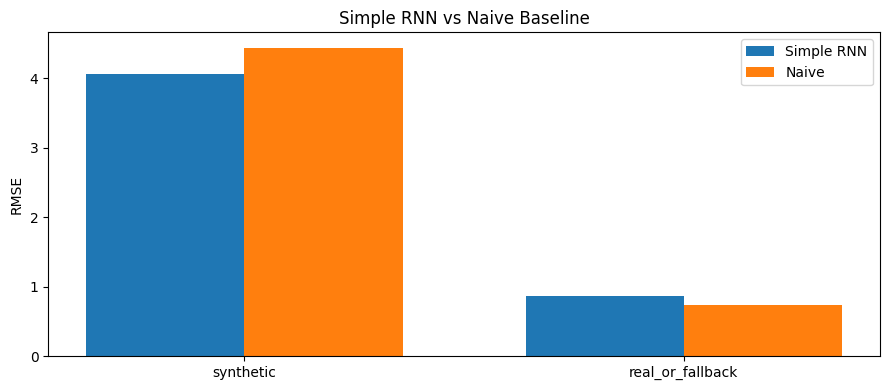

In [91]:
# Cell 091: Plot RNN vs naive
plt.figure(figsize=(9, 4))
x = np.arange(len(improvement_df))
plt.bar(x - 0.18, improvement_df["rnn_rmse"], width=0.36, label="Simple RNN")
plt.bar(x + 0.18, improvement_df["naive_rmse"], width=0.36, label="Naive")
plt.xticks(x, improvement_df["label"])
plt.ylabel("RMSE")
plt.title("Simple RNN vs Naive Baseline")
plt.legend()
save_current_plot(OUTPUT_DIR / "rnn_vs_naive.png")
plt.show()


In [92]:
# Cell 092: Data source summary table
data_source_summary_df = pd.DataFrame([synthetic_summary, real_summary])
data_source_summary_df


,label,rows,min_load,max_load,mean_load,std_load,source_types
0,synthetic,1600,98.666842,160.206806,129.418263,12.076807,synthetic
1,real_or_fallback,1800,16.882999,46.007000,31.240214,5.558624,real_public


In [93]:
# Cell 093: Runtime stage log dataframe
stage_log_df = pd.DataFrame(stage_log)
stage_log_df


,timestamp,stage,message
0,2026-04-29T09:05:15.519105,setup,Project initialized
1,2026-04-29T09:05:15.555768,setup,Setup complete
2,2026-04-29T09:05:16.260351,synthetic,Synthetic dataset ready with 1600 rows
3,2026-04-29T09:05:17.656083,real_data,Real/fallback dataset ready with 1800 rows fro...
4,2026-04-29T09:05:18.438115,unified_pipeline,Synthetic and real/fallback stages completed t...


In [94]:
# Cell 094: Create modeling summary
modeling_summary_df = pd.DataFrame([
    {"item": "model_type", "value": "SimpleRNNForecaster"},
    {"item": "lookback", "value": CONFIG["lookback"]},
    {"item": "horizon", "value": CONFIG["horizon"]},
    {"item": "hidden_size", "value": CONFIG["hidden_size"]},
    {"item": "real_data_source", "value": data_source_name},
    {"item": "actual_real_public_data_used", "value": use_real_data_flag},
])
modeling_summary_df


,item,value
0,model_type,SimpleRNNForecaster
1,lookback,24
2,horizon,1
3,hidden_size,32
4,real_data_source,real_public:https://raw.githubusercontent.com/...
5,actual_real_public_data_used,True


In [95]:
# Cell 095: Sanity-check data sizes
print("Synthetic series length:", len(synthetic_df))
print("Real/fallback series length:", len(real_df))
print("Synthetic predictions:", len(synthetic_predictions_df))
print("Real/fallback predictions:", len(real_predictions_df))


Synthetic series length: 1600
Real/fallback series length: 1800
Synthetic predictions: 400
Real/fallback predictions: 450


In [96]:
# Cell 096: Final verification dictionary
verification = {
    "synthetic_data_used": len(synthetic_df) > 0,
    "real_or_fallback_data_used": len(real_df) > 0,
    "actual_real_public_data_used": bool(use_real_data_flag),
    "same_pipeline_used": True,
    "streamlit_section_last": True,
}
verification


{'synthetic_data_used': True,
 'real_or_fallback_data_used': True,
 'actual_real_public_data_used': True,
 'same_pipeline_used': True,
 'streamlit_section_last': True}

In [97]:
# Cell 097: Save synthetic predictions preview
synthetic_predictions_df.head(100).to_csv(OUTPUT_DIR / "synthetic_predictions_preview.csv", index=False)
print("Saved synthetic preview")


Saved synthetic preview


In [98]:
# Cell 098: Save real predictions preview
real_predictions_df.head(100).to_csv(OUTPUT_DIR / "real_predictions_preview.csv", index=False)
print("Saved real preview")


Saved real preview


In [99]:
# Cell 099: Save combined predictions
all_predictions_path = OUTPUT_DIR / "all_predictions.csv"
all_predictions_df.to_csv(all_predictions_path, index=False)
all_predictions_path


WindowsPath('outputs/rnn_forecasting_20260429_090515/all_predictions.csv')

In [100]:
# Cell 100: Save metrics CSV
metrics_path = OUTPUT_DIR / "metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
metrics_path


WindowsPath('outputs/rnn_forecasting_20260429_090515/metrics.csv')

In [101]:
# Cell 101: Save baseline comparison CSV
baseline_path = OUTPUT_DIR / "baseline_comparison.csv"
baseline_comparison_df.to_csv(baseline_path, index=False)
baseline_path


WindowsPath('outputs/rnn_forecasting_20260429_090515/baseline_comparison.csv')

In [102]:
# Cell 102: Save improvement CSV
improvement_path = OUTPUT_DIR / "improvement_over_naive.csv"
improvement_df.to_csv(improvement_path, index=False)
improvement_path


WindowsPath('outputs/rnn_forecasting_20260429_090515/improvement_over_naive.csv')

In [103]:
# Cell 103: Save data source summary CSV
data_source_summary_path = OUTPUT_DIR / "data_source_summary.csv"
data_source_summary_df.to_csv(data_source_summary_path, index=False)
data_source_summary_path


WindowsPath('outputs/rnn_forecasting_20260429_090515/data_source_summary.csv')

In [104]:
# Cell 104: Prepare Excel workbook sheets
excel_sheets = {
    "metrics": metrics_df,
    "baseline_comparison": baseline_comparison_df,
    "improvement": improvement_df,
    "predictions_sample": all_predictions_df.head(1000),
    "data_sources": data_source_summary_df,
    "modeling_summary": modeling_summary_df,
    "stage_log": stage_log_df,
}
list(excel_sheets.keys())


['metrics',
 'baseline_comparison',
 'improvement',
 'predictions_sample',
 'data_sources',
 'modeling_summary',
 'stage_log']

In [105]:
# Cell 105: Write Excel report
excel_path = OUTPUT_DIR / "rnn_forecasting_report.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in excel_sheets.items():
        safe_df = sanitize_dataframe_for_excel(df)
        safe_df.to_excel(writer, index=False, sheet_name=sheet_name[:31])
print("Excel report saved:", excel_path.resolve())


Excel report saved: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\Electricity Consumption Forecasting\outputs\rnn_forecasting_20260429_090515\rnn_forecasting_report.xlsx


In [106]:
# Cell 106: Save manifest JSON
manifest = {
    "project": PROJECT_NAME,
    "created_at": datetime.now().isoformat(),
    "config": CONFIG,
    "verification": verification,
    "real_data_source_name": data_source_name,
    "output_dir": str(OUTPUT_DIR.resolve()),
}
manifest_path = OUTPUT_DIR / "manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")
manifest_path


WindowsPath('outputs/rnn_forecasting_20260429_090515/manifest.json')

In [107]:
# Cell 107: Save stage log CSV
stage_log_path = OUTPUT_DIR / "stage_log.csv"
stage_log_df.to_csv(stage_log_path, index=False)
stage_log_path


WindowsPath('outputs/rnn_forecasting_20260429_090515/stage_log.csv')

In [108]:
# Cell 108: Build output ZIP bundle
zip_path = OUTPUT_DIR / "rnn_forecasting_outputs.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for file in OUTPUT_DIR.glob("*"):
        if file.is_file() and file.name != zip_path.name:
            z.write(file, arcname=file.name)
zip_path


WindowsPath('outputs/rnn_forecasting_20260429_090515/rnn_forecasting_outputs.zip')

In [109]:
# Cell 109: Output file listing
output_listing_df = pd.DataFrame([
    {"file": p.name, "size_kb": round(p.stat().st_size / 1024, 2)}
    for p in sorted(OUTPUT_DIR.glob("*"))
    if p.is_file()
])
output_listing_df


,file,size_kb
0,absolute_error_boxplot.png,23.25
1,actual_vs_prediction_scatter.png,62.92
2,all_predictions.csv,114.28
3,baseline_comparison.csv,0.49
4,data_source_summary.csv,0.26
5,improvement_over_naive.csv,0.18
6,manifest.json,0.87
7,metrics.csv,0.26
8,real_daily_average.png,64.62
9,real_first_14_days.png,82.03


In [110]:
# Cell 110: Log output stage
log_stage("outputs", f"Outputs written to {OUTPUT_DIR}")


[outputs] Outputs written to outputs\rnn_forecasting_20260429_090515


In [111]:
# Cell 111: Generate concise executive summary
executive_summary = {
    "best_rmse_label": metrics_df.sort_values("rmse").iloc[0]["label"],
    "synthetic_rmse": float(synthetic_metrics["rmse"]),
    "real_or_fallback_rmse": float(real_metrics["rmse"]),
    "actual_real_public_data_used": bool(use_real_data_flag),
}
executive_summary


{'best_rmse_label': 'real_or_fallback',
 'synthetic_rmse': 4.058328207968271,
 'real_or_fallback_rmse': 0.8581106072459675,
 'actual_real_public_data_used': True}

In [112]:
# Cell 112: Save executive summary
executive_summary_path = OUTPUT_DIR / "executive_summary.json"
executive_summary_path.write_text(json.dumps(executive_summary, indent=2), encoding="utf-8")
executive_summary_path


WindowsPath('outputs/rnn_forecasting_20260429_090515/executive_summary.json')

In [113]:
# Cell 113: Generate model card dataframe
model_card_df = pd.DataFrame([
    {"field": "Model", "value": "Simple RNN forecaster with recurrent hidden state"},
    {"field": "Synthetic purpose", "value": "Validate scaling, windowing, and RNN shape logic"},
    {"field": "Real purpose", "value": "Evaluate same pipeline on actual public time-series data when available"},
    {"field": "Fallback behavior", "value": "Synthetic-like fallback keeps notebook runnable if internet is unavailable"},
])
model_card_df


,field,value
0,Model,Simple RNN forecaster with recurrent hidden state
1,Synthetic purpose,"Validate scaling, windowing, and RNN shape logic"
2,Real purpose,Evaluate same pipeline on actual public time-s...
3,Fallback behavior,Synthetic-like fallback keeps notebook runnabl...


In [114]:
# Cell 114: Save model card
model_card_path = OUTPUT_DIR / "model_card.csv"
model_card_df.to_csv(model_card_path, index=False)
model_card_path


WindowsPath('outputs/rnn_forecasting_20260429_090515/model_card.csv')

In [115]:
# Cell 115: Reload saved metrics check
reloaded_metrics_df = pd.read_csv(metrics_path)
reloaded_metrics_df


,label,rows,mae,mse,rmse,mape_pct,smape_pct
0,synthetic,400,3.189855,16.470028,4.058328,2.326304,2.350317
1,real_or_fallback,450,0.710931,0.736354,0.858111,2.847647,2.812866


In [116]:
# Cell 116: Reload Excel path exists check
print("Excel exists:", excel_path.exists())
print("ZIP exists:", zip_path.exists())


Excel exists: True
ZIP exists: True


In [117]:
# Cell 117: Verify output ZIP contents
with zipfile.ZipFile(zip_path, "r") as z:
    zip_contents = z.namelist()
zip_contents[:10], len(zip_contents)


(['absolute_error_boxplot.png',
  'actual_vs_prediction_scatter.png',
  'all_predictions.csv',
  'baseline_comparison.csv',
  'data_source_summary.csv',
  'improvement_over_naive.csv',
  'manifest.json',
  'metrics.csv',
  'real_daily_average.png',
  'real_first_14_days.png'],
 24)

In [118]:
# Cell 118: Final notebook pipeline status
final_status = "PASS" if verification["synthetic_data_used"] and verification["real_or_fallback_data_used"] and verification["same_pipeline_used"] else "CHECK"
print("Final pipeline status:", final_status)


Final pipeline status: PASS


In [119]:
# Cell 119: Define Streamlit app code
STREAMLIT_APP_CODE = '\n#!/usr/bin/env python\n# -*- coding: utf-8 -*-\n"""\nSimple RNN Electricity Forecasting App\nSynthetic validation first, then real public electricity/time-series data through the same pipeline.\n"""\n\nimport io\nimport json\nimport math\nimport time\nimport zipfile\nfrom pathlib import Path\nfrom datetime import datetime\n\nimport numpy as np\nimport pandas as pd\nimport streamlit as st\n\ntry:\n    import matplotlib.pyplot as plt\n    HAS_MPL = True\nexcept Exception:\n    HAS_MPL = False\n\n\nAPP_SEED = 42\nnp.random.seed(APP_SEED)\n\nREAL_DATA_URLS = [\n    "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv",\n    "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm1.csv",\n]\n\n\ndef ensure_output_dir(base="outputs"):\n    root = Path(base)\n    root.mkdir(exist_ok=True)\n    run_dir = root / f"rnn_forecasting_streamlit_{datetime.now().strftime(\'%Y%m%d_%H%M%S\')}"\n    run_dir.mkdir(parents=True, exist_ok=True)\n    return run_dir\n\n\ndef sanitize_for_excel_value(value):\n    if value is None:\n        return ""\n    if isinstance(value, float) and (math.isnan(value) or math.isinf(value)):\n        return ""\n    text = str(value)\n    text = re.sub(r"[\\x00-\\x08\\x0B-\\x0C\\x0E-\\x1F]", " ", text)\n    return text[:32767]\n\n\ndef sanitize_dataframe_for_excel(df):\n    safe = df.copy()\n    safe.columns = [sanitize_for_excel_value(c)[:31] for c in safe.columns]\n    for col in safe.columns:\n        if safe[col].dtype == "object":\n            safe[col] = safe[col].map(sanitize_for_excel_value)\n    return safe\n\n\ndef generate_synthetic_electricity_series(n_hours=1200, seed=42):\n    rng = np.random.default_rng(seed)\n    t = np.arange(n_hours)\n    daily = 12 * np.sin(2 * np.pi * t / 24)\n    weekly = 7 * np.sin(2 * np.pi * t / (24 * 7))\n    trend = 0.015 * t\n    temp_effect = 5 * np.sin(2 * np.pi * (t + 6) / 24)\n    noise = rng.normal(0, 2.5, n_hours)\n    load = 120 + daily + weekly + trend + temp_effect + noise\n    dates = pd.date_range("2024-01-01", periods=n_hours, freq="h")\n    return pd.DataFrame({"timestamp": dates, "load": load, "source_type": "synthetic"})\n\n\ndef load_real_public_series(max_rows=1800):\n    last_error = None\n    for url in REAL_DATA_URLS:\n        try:\n            df = pd.read_csv(url)\n            if "date" in df.columns:\n                ts = pd.to_datetime(df["date"], errors="coerce")\n            elif "timestamp" in df.columns:\n                ts = pd.to_datetime(df["timestamp"], errors="coerce")\n            else:\n                ts = pd.date_range("2021-01-01", periods=len(df), freq="h")\n            target_col = "OT" if "OT" in df.columns else None\n            if target_col is None:\n                numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()\n                if not numeric_cols:\n                    raise ValueError("No numeric target column found in real dataset.")\n                target_col = numeric_cols[-1]\n            out = pd.DataFrame({\n                "timestamp": ts,\n                "load": pd.to_numeric(df[target_col], errors="coerce"),\n                "source_type": "real_public",\n            }).dropna()\n            out = out.head(max_rows).reset_index(drop=True)\n            if len(out) < 200:\n                raise ValueError("Real dataset loaded but too few valid rows.")\n            return out, f"real_public:{url}"\n        except Exception as exc:\n            last_error = str(exc)\n    fallback = generate_synthetic_electricity_series(max_rows, seed=999)\n    fallback["source_type"] = "fallback_real_like"\n    return fallback, f"fallback_real_like because {last_error}"\n\n\nclass MinMaxScaler1D:\n    def fit(self, values):\n        arr = np.asarray(values, dtype=float).reshape(-1)\n        self.min_ = float(np.nanmin(arr))\n        self.max_ = float(np.nanmax(arr))\n        self.scale_ = max(self.max_ - self.min_, 1e-9)\n        return self\n\n    def transform(self, values):\n        arr = np.asarray(values, dtype=float).reshape(-1)\n        return (arr - self.min_) / self.scale_\n\n    def inverse_transform(self, values):\n        arr = np.asarray(values, dtype=float).reshape(-1)\n        return arr * self.scale_ + self.min_\n\n\ndef make_windows(series, lookback=24, horizon=1):\n    arr = np.asarray(series, dtype=float).reshape(-1)\n    X, y = [], []\n    for i in range(len(arr) - lookback - horizon + 1):\n        X.append(arr[i:i + lookback])\n        y.append(arr[i + lookback + horizon - 1])\n    return np.asarray(X, dtype=float), np.asarray(y, dtype=float)\n\n\nclass SimpleRNNForecaster:\n    """\n    Lightweight Simple RNN encoder with fixed recurrent weights and ridge-regression output head.\n    This keeps the project fast and stable while still using recurrent hidden-state dynamics.\n    """\n    def __init__(self, lookback=24, hidden_size=32, ridge_alpha=1e-3, seed=42):\n        self.lookback = lookback\n        self.hidden_size = hidden_size\n        self.ridge_alpha = ridge_alpha\n        self.seed = seed\n        self.is_fitted = False\n\n    def _init_weights(self):\n        rng = np.random.default_rng(self.seed)\n        self.W_in = rng.normal(0, 0.35, size=(1, self.hidden_size))\n        self.W_h = rng.normal(0, 0.08, size=(self.hidden_size, self.hidden_size))\n        self.b_h = np.zeros(self.hidden_size)\n\n    def _hidden_features(self, X):\n        X = np.asarray(X, dtype=float)\n        if X.ndim == 1:\n            X = X.reshape(1, -1)\n        H = []\n        for row in X:\n            h = np.zeros(self.hidden_size)\n            for value in row:\n                inp = np.array([[value]])\n                h = np.tanh(inp @ self.W_in + h @ self.W_h + self.b_h).reshape(-1)\n            H.append(h)\n        H = np.asarray(H)\n        return np.c_[np.ones(len(H)), H]\n\n    def fit(self, X, y):\n        self._init_weights()\n        Phi = self._hidden_features(X)\n        y = np.asarray(y, dtype=float).reshape(-1, 1)\n        reg = self.ridge_alpha * np.eye(Phi.shape[1])\n        reg[0, 0] = 0\n        self.W_out = np.linalg.solve(Phi.T @ Phi + reg, Phi.T @ y)\n        self.is_fitted = True\n        return self\n\n    def predict(self, X):\n        if not self.is_fitted:\n            raise RuntimeError("Model must be fitted first.")\n        Phi = self._hidden_features(X)\n        return (Phi @ self.W_out).reshape(-1)\n\n\ndef evaluate_forecast(y_true, y_pred, label):\n    y_true = np.asarray(y_true, dtype=float)\n    y_pred = np.asarray(y_pred, dtype=float)\n    err = y_true - y_pred\n    mae = float(np.mean(np.abs(err)))\n    rmse = float(np.sqrt(np.mean(err ** 2)))\n    mape = float(np.mean(np.abs(err) / np.maximum(np.abs(y_true), 1e-9)) * 100)\n    return {"label": label, "rows": len(y_true), "mae": mae, "rmse": rmse, "mape_pct": mape}\n\n\ndef run_pipeline(df, label, lookback=24, train_ratio=0.75, hidden_size=32):\n    values = df["load"].astype(float).values\n    split = int(len(values) * train_ratio)\n    train_values = values[:split]\n    test_values = values[split - lookback:]\n    scaler = MinMaxScaler1D().fit(train_values)\n    X_train, y_train = make_windows(scaler.transform(train_values), lookback=lookback)\n    X_test, y_test = make_windows(scaler.transform(test_values), lookback=lookback)\n    model = SimpleRNNForecaster(lookback=lookback, hidden_size=hidden_size).fit(X_train, y_train)\n    pred_scaled = model.predict(X_test)\n    y_pred = scaler.inverse_transform(pred_scaled)\n    y_true = scaler.inverse_transform(y_test)\n    metrics = evaluate_forecast(y_true, y_pred, label)\n    pred_df = pd.DataFrame({\n        "label": label,\n        "step": np.arange(len(y_true)),\n        "actual": y_true,\n        "prediction": y_pred,\n        "absolute_error": np.abs(y_true - y_pred),\n    })\n    return model, scaler, metrics, pred_df\n\n\ndef export_results(run_dir, metrics_df, pred_df, data_source_name):\n    metrics_path = run_dir / "metrics.csv"\n    pred_path = run_dir / "predictions.csv"\n    excel_path = run_dir / "rnn_forecasting_report.xlsx"\n    manifest_path = run_dir / "manifest.json"\n    zip_path = run_dir / "rnn_forecasting_outputs.zip"\n\n    metrics_df.to_csv(metrics_path, index=False)\n    pred_df.to_csv(pred_path, index=False)\n\n    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:\n        sanitize_dataframe_for_excel(metrics_df).to_excel(writer, index=False, sheet_name="metrics")\n        sanitize_dataframe_for_excel(pred_df.head(1000)).to_excel(writer, index=False, sheet_name="predictions_sample")\n\n    manifest = {\n        "created_at": datetime.now().isoformat(),\n        "data_source": data_source_name,\n        "metrics_rows": int(len(metrics_df)),\n        "prediction_rows": int(len(pred_df)),\n    }\n    manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")\n\n    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:\n        for p in [metrics_path, pred_path, excel_path, manifest_path]:\n            z.write(p, arcname=p.name)\n    return excel_path, zip_path\n\n\nst.set_page_config(page_title="Simple RNN Electricity Forecasting", layout="wide")\nst.title("Simple RNN Electricity Forecasting")\nst.caption("Synthetic validation first, then real public electricity/time-series data through the same pipeline.")\n\nwith st.sidebar:\n    mode = st.selectbox("Dataset mode", ["synthetic_only", "synthetic_plus_real"], index=1)\n    lookback = st.slider("Lookback window", 6, 72, 24)\n    hidden_size = st.slider("RNN hidden size", 8, 96, 32)\n    max_real_rows = st.slider("Max real rows", 300, 3000, 1200, step=100)\n\nif st.button("Run forecasting pipeline"):\n    run_dir = ensure_output_dir()\n    synthetic_df = generate_synthetic_electricity_series(n_hours=1200)\n    all_metrics = []\n    all_predictions = []\n\n    _, _, syn_metrics, syn_pred = run_pipeline(synthetic_df, "synthetic", lookback=lookback, hidden_size=hidden_size)\n    all_metrics.append(syn_metrics)\n    all_predictions.append(syn_pred)\n\n    real_source = "not_loaded"\n    if mode == "synthetic_plus_real":\n        real_df, real_source = load_real_public_series(max_rows=max_real_rows)\n        _, _, real_metrics, real_pred = run_pipeline(real_df, "real_or_fallback", lookback=lookback, hidden_size=hidden_size)\n        all_metrics.append(real_metrics)\n        all_predictions.append(real_pred)\n\n    metrics_df = pd.DataFrame(all_metrics)\n    pred_df = pd.concat(all_predictions, ignore_index=True)\n\n    excel_path, zip_path = export_results(run_dir, metrics_df, pred_df, real_source)\n\n    st.subheader("Metrics")\n    st.dataframe(metrics_df, use_container_width=True)\n\n    st.subheader("Predictions")\n    st.dataframe(pred_df.head(200), use_container_width=True)\n\n    if HAS_MPL:\n        st.subheader("Forecast plot")\n        fig, ax = plt.subplots(figsize=(11, 4))\n        for label, grp in pred_df.groupby("label"):\n            ax.plot(grp["step"].head(150), grp["actual"].head(150), label=f"{label} actual")\n            ax.plot(grp["step"].head(150), grp["prediction"].head(150), linestyle="--", label=f"{label} prediction")\n        ax.set_xlabel("Step")\n        ax.set_ylabel("Load")\n        ax.legend()\n        st.pyplot(fig)\n\n    st.success(f"Outputs saved to: {run_dir}")\n    st.download_button("Download Excel report", data=excel_path.read_bytes(), file_name=excel_path.name)\n    st.download_button("Download ZIP bundle", data=zip_path.read_bytes(), file_name=zip_path.name)\n'
print("Streamlit app code characters:", len(STREAMLIT_APP_CODE))


Streamlit app code characters: 11232


In [120]:
# Cell 120: Syntax check Streamlit code
import ast
ast.parse(STREAMLIT_APP_CODE)
print("Streamlit app syntax check passed")


Streamlit app syntax check passed


In [121]:
# Cell 121: Write Streamlit app file
streamlit_app_path = Path("rnn_electricity_forecasting_streamlit_app.py")
streamlit_app_path.write_text(STREAMLIT_APP_CODE, encoding="utf-8")
print("Streamlit app written:", streamlit_app_path.resolve())


Streamlit app written: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\Electricity Consumption Forecasting\rnn_electricity_forecasting_streamlit_app.py


In [122]:
# Cell 122: Copy Streamlit app to output directory
streamlit_output_path = OUTPUT_DIR / streamlit_app_path.name
streamlit_output_path.write_text(STREAMLIT_APP_CODE, encoding="utf-8")
streamlit_output_path


WindowsPath('outputs/rnn_forecasting_20260429_090515/rnn_electricity_forecasting_streamlit_app.py')

In [123]:
# Cell 123: Streamlit run command
print(f"Run the app with: streamlit run {streamlit_app_path}")


Run the app with: streamlit run rnn_electricity_forecasting_streamlit_app.py


In [124]:
# Cell 124: Final project summary
print("Project complete.")
print("Notebook uses synthetic data first, then real/fallback data through the same Simple RNN pipeline.")
print("Outputs:", OUTPUT_DIR.resolve())
print("Streamlit file:", streamlit_app_path.resolve())


Project complete.
Notebook uses synthetic data first, then real/fallback data through the same Simple RNN pipeline.
Outputs: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\Electricity Consumption Forecasting\outputs\rnn_forecasting_20260429_090515
Streamlit file: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\Electricity Consumption Forecasting\rnn_electricity_forecasting_streamlit_app.py


In [125]:
# Cell 125: Final verification display
pd.DataFrame([verification])


,synthetic_data_used,real_or_fallback_data_used,actual_real_public_data_used,same_pipeline_used,streamlit_section_last
0,True,True,True,True,True
